# LSTM-Bitcoin reference evaluation

This is a read-only evidence notebook for the checked-in `reference-v1`
run. It verifies and summarizes released artifacts; **it does not retrain,
tune, or select a model**. Rebuild the evidence with the documented CLI,
review it, and only then execute this notebook.

## tl;dr

The next cell first checks the pinned data, the complete result bundle,
the four published figures, and their recorded SHA-256 digests. Its summary
is generated from those verified files so the notebook cannot silently
preserve a stale performance claim.

In [1]:
import csv
import json
from html import escape
from pathlib import Path

from IPython.display import HTML, SVG, Markdown, display

from lstm_bitcoin.artifacts import sha256_path, verify_checksums
from lstm_bitcoin.data import validate_reference_data


def find_repository_root(start: Path) -> Path:
    """Find the checkout without assuming the notebook server's directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "src" / "lstm_bitcoin"
        ).is_dir():
            return candidate
    raise FileNotFoundError("run this notebook from inside the LSTM-Bitcoin checkout")


ROOT = find_repository_root(Path.cwd())
DATA_PATH = ROOT / "data" / "btc_usd_daily.csv"
SOURCE_MANIFEST_PATH = ROOT / "data" / "source-manifest.json"
CONFIG_PATH = ROOT / "configs" / "reference.toml"
RUN_DIRECTORY = ROOT / "evaluation" / "results" / "reference-v1"
FIGURE_DIRECTORY = ROOT / "docs" / "assets"

REQUIRED_RUN_FILES = {
    "fold_metrics.csv",
    "folds.csv",
    "manifest.json",
    "metrics.json",
    "predictions.csv",
    "seed_metrics.csv",
    "seed_predictions.csv",
    "signal_metrics.csv",
    "signal_simulation.csv",
    "training.csv",
}
REQUIRED_FIGURES = {
    "forecast_mae.svg",
    "forecast_scatter.svg",
    "signal_equity.svg",
    "walk_forward_folds.svg",
}


def require(condition: bool, message: str) -> None:
    if not condition:
        raise ValueError(message)


def read_json(path: Path) -> dict[str, object]:
    with path.open("r", encoding="utf-8") as handle:
        document = json.load(handle)
    require(isinstance(document, dict), f"expected a JSON object: {path}")
    return document


def read_rows(path: Path) -> list[dict[str, str]]:
    with path.open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


def format_value(value: object) -> str:
    if value is None:
        return "N/A"
    if isinstance(value, bool):
        return "yes" if value else "no"
    if isinstance(value, float):
        return f"{value:.6g}"
    if isinstance(value, (list, tuple)):
        return ", ".join(format_value(item) for item in value)
    return str(value)


def table_cell(row: dict[str, object], column: str) -> str:
    return f"<td>{escape(format_value(row.get(column, '')))}</td>"


def table_row(row: dict[str, object], columns: tuple[str, ...]) -> str:
    cells = "".join(table_cell(row, column) for column in columns)
    return f"<tr>{cells}</tr>"


def bounded_table(
    rows: list[dict[str, object]],
    columns: tuple[str, ...],
    *,
    max_rows: int,
) -> HTML:
    """Render a deliberately bounded HTML table without a pandas dependency."""
    require(max_rows > 0, "max_rows must be positive")
    shown = rows[:max_rows]
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join(table_row(row, columns) for row in shown)
    note = (
        f"<p><em>Showing {len(shown)} of {len(rows)} rows.</em></p>"
        if len(rows) > len(shown)
        else f"<p><em>{len(shown)} rows.</em></p>"
    )
    return HTML(
        "<div style='overflow-x:auto'>"
        "<table>"
        f"<thead><tr>{header}</tr></thead><tbody>{body}</tbody>"
        "</table>"
        f"{note}</div>"
    )


evidence_paths = (
    DATA_PATH,
    SOURCE_MANIFEST_PATH,
    CONFIG_PATH,
    RUN_DIRECTORY,
    FIGURE_DIRECTORY,
)
missing = [path for path in evidence_paths if not path.exists()]
if missing:
    rendered = "\n".join(f"- {path.relative_to(ROOT)}" for path in missing)
    raise FileNotFoundError(
        "The reviewed reference evidence is not complete. Generate and review "
        f"it before executing this notebook:\n{rendered}"
    )

validate_reference_data(DATA_PATH, SOURCE_MANIFEST_PATH)
verified_run_files = set(verify_checksums(RUN_DIRECTORY))
verified_figures = set(verify_checksums(FIGURE_DIRECTORY))
require(
    verified_run_files == REQUIRED_RUN_FILES,
    "reference-v1/SHA256SUMS does not enumerate the exact released result set",
)
require(
    verified_figures == REQUIRED_FIGURES,
    "docs/assets/SHA256SUMS does not enumerate the exact four released figures",
)

source_manifest = read_json(SOURCE_MANIFEST_PATH)
run_manifest = read_json(RUN_DIRECTORY / "manifest.json")
metrics = read_json(RUN_DIRECTORY / "metrics.json")
prices = read_rows(DATA_PATH)
folds = read_rows(RUN_DIRECTORY / "folds.csv")
fold_metrics = read_rows(RUN_DIRECTORY / "fold_metrics.csv")
predictions = read_rows(RUN_DIRECTORY / "predictions.csv")
seed_metrics = read_rows(RUN_DIRECTORY / "seed_metrics.csv")
signal_metrics = read_rows(RUN_DIRECTORY / "signal_metrics.csv")

inputs = run_manifest["inputs"]
require(isinstance(inputs, dict), "run manifest inputs must be an object")
require(inputs["data_sha256"] == sha256_path(DATA_PATH), "run/data digest mismatch")
require(
    inputs["source_manifest_sha256"] == sha256_path(SOURCE_MANIFEST_PATH),
    "run/source-manifest digest mismatch",
)
require(
    inputs["config_sha256"] == sha256_path(CONFIG_PATH),
    "run/config digest mismatch",
)

recorded_artifacts = run_manifest["artifacts"]
require(isinstance(recorded_artifacts, dict), "run artifact index must be an object")
require(
    set(recorded_artifacts) == REQUIRED_RUN_FILES - {"manifest.json"},
    "manifest artifact index is incomplete or contains an unexpected file",
)
for filename, expected_digest in recorded_artifacts.items():
    require(
        sha256_path(RUN_DIRECTORY / filename) == expected_digest,
        f"manifest digest mismatch for {filename}",
    )

processed = source_manifest["processed"]
require(isinstance(processed, dict), "processed data manifest must be an object")
require(len(prices) == processed["rows"], "processed data row count mismatch")
require(prices[0]["date"] == processed["start_date"], "processed start date mismatch")
require(prices[-1]["date"] == processed["end_date"], "processed end date mismatch")

period = metrics["out_of_sample_period"]
require(isinstance(period, dict), "out-of-sample period must be an object")
models = metrics["models"]
require(isinstance(models, dict) and models, "metrics must contain released models")
expected_observations = int(period["observations"])
for model_name in models:
    model_rows = [row for row in predictions if row["model"] == model_name]
    target_dates = [row["target_date"] for row in model_rows]
    require(
        len(model_rows) == expected_observations == len(set(target_dates)),
        f"{model_name} predictions are incomplete or duplicate a target date",
    )

comparison = metrics["comparison"]
require(isinstance(comparison, dict), "comparison must be an object")
interval = comparison.get("block_bootstrap_95pct_interval")
require(isinstance(interval, list) and len(interval) == 2, "missing bootstrap interval")
difference = float(comparison["lstm_minus_best_baseline_mae"])
interval_text = f"[{float(interval[0]):.6g}, {float(interval[1]):.6g}]"
direction = "lower" if difference < 0 else "higher"
verdict = "did" if comparison["beats_best_baseline"] else "did not"
source_manifest_digest = sha256_path(SOURCE_MANIFEST_PATH)
run_manifest_digest = sha256_path(RUN_DIRECTORY / "manifest.json")
display(
    Markdown(
        f"**Integrity checks passed.** The released LSTM ensemble {verdict} beat the "
        f"best MAE baseline (`{comparison['best_baseline']}`): its MAE was "
        f"{abs(difference):.6g} {direction}. The 95% moving-block bootstrap interval "
        f"for LSTM minus baseline MAE is {interval_text}. These are historical "
        "out-of-sample results, not evidence of future profitability. "
        f"Evidence fingerprints: source manifest `{source_manifest_digest}`; "
        f"run manifest `{run_manifest_digest}`."
    )
)
display(
    bounded_table(
        [
            {
                "verified component": "processed daily data",
                "files": 1,
                "status": "pinned source and digest verified",
            },
            {
                "verified component": "reference result bundle",
                "files": len(verified_run_files),
                "status": "all SHA-256 entries verified",
            },
            {
                "verified component": "published evidence figures",
                "files": len(verified_figures),
                "status": "all SHA-256 entries verified",
            },
        ],
        ("verified component", "files", "status"),
        max_rows=3,
    )
)

**Integrity checks passed.** The released LSTM ensemble did not beat the best MAE baseline (`zero_return`): its MAE was 5.23563e-05 higher. The 95% moving-block bootstrap interval for LSTM minus baseline MAE is [-6.39818e-05, 0.000159756]. These are historical out-of-sample results, not evidence of future profitability. Evidence fingerprints: source manifest `9ee780ad64eed2a2efaf6c5be4d6a3cdd8463a944e290516e3ddd08fb40beef6`; run manifest `0b35047f2e7722ac6af6f8fe85f3d9b51a344836821b01a174aa8d5ee1fc0c43`.

verified component,files,status
processed daily data,1,pinned source and digest verified
reference result bundle,10,all SHA-256 entries verified
published evidence figures,4,all SHA-256 entries verified


## Context & Methods

The study forecasts the next close-to-close daily Bitcoin log return from a
30-day window of price-derived features available by the forecast origin.
Calendar-based expanding folds keep training, validation, and test periods
strictly ordered. The released LSTM is an ensemble of three deterministic CPU
seeds and is compared with zero-return, historical-mean, and ridge baselines.

Forecast MAE is the primary evidence. A long/flat signal simulation is shown
only as secondary, idealized sensitivity analysis with explicit turnover costs;
it omits market impact, taxes, custody, and outages. No cell below fits a model.

In [2]:
experiment = run_manifest["experiment"]
experiment_settings = experiment["experiment"]
lstm_settings = experiment["lstm"]
feature_details = run_manifest["features"]
layer_count = lstm_settings["layers"]
hidden_size = lstm_settings["hidden_size"]
seed_values = experiment_settings["seeds"]
design_rows = [
    {"item": "target", "released setting": metrics["forecast_target"]},
    {
        "item": "data window",
        "released setting": (
            f"{experiment_settings['start_date']} to {experiment_settings['end_date']}"
        ),
    },
    {
        "item": "lookback / horizon",
        "released setting": (
            f"{experiment_settings['lookback']} / {experiment_settings['horizon']} days"
        ),
    },
    {"item": "features", "released setting": feature_details["names"]},
    {
        "item": "test folds",
        "released setting": (
            f"annual {experiment_settings['first_test_year']}-"
            f"{experiment_settings['last_test_year']}"
        ),
    },
    {
        "item": "validation",
        "released setting": (
            f"{experiment_settings['validation_years']} calendar year before each test"
        ),
    },
    {
        "item": "LSTM",
        "released setting": (
            f"{layer_count} layer, hidden size {hidden_size}, seeds {seed_values}"
        ),
    },
    {
        "item": "primary transaction cost",
        "released setting": (
            f"{experiment_settings['transaction_cost_bps']:g} bps per one-way turnover"
        ),
    },
]
display(bounded_table(design_rows, ("item", "released setting"), max_rows=10))

item,released setting
target,next-day close-to-close log return
data window,2013-01-01 to 2025-12-31
lookback / horizon,30 / 1 days
features,"log_return_1d, log_return_7d, log_return_30d, realized_volatility_7d, realized_volatility_30d"
test folds,annual 2018-2025
validation,1 calendar year before each test
LSTM,"1 layer, hidden size 16, seeds [7, 17, 29]"
primary transaction cost,10 bps per one-way turnover


## Data

The maintained analysis uses only the Coin Metrics Community Data daily
`PriceUSD` series. The source commit, raw file digest, transformation, output
digest, coverage, attribution, and separate CC BY-NC 4.0 terms are pinned in
`data/source-manifest.json`. No legacy macro, ETF, search-trend, or proprietary
vendor columns enter this study.

In [3]:
source = source_manifest["source"]
provenance_rows = [
    {"field": "attribution", "value": source["attribution"]},
    {"field": "license", "value": source["license"]},
    {"field": "timezone", "value": source["timezone"]},
    {"field": "timestamp convention", "value": source["timestamp_convention"]},
    {"field": "source repository", "value": source["repository"]},
    {"field": "pinned commit", "value": source["commit"]},
    {"field": "raw SHA-256", "value": source["sha256"]},
    {"field": "processed SHA-256", "value": processed["sha256"]},
    {"field": "processed rows", "value": processed["rows"]},
    {
        "field": "processed range",
        "value": f"{processed['start_date']} to {processed['end_date']}",
    },
]
display(bounded_table(provenance_rows, ("field", "value"), max_rows=10))

price_preview = prices[:3] + prices[-3:]
display(Markdown("### Bounded processed-data preview"))
display(bounded_table(price_preview, ("date", "close_usd"), max_rows=6))

field,value
attribution,"Coin Metrics Community Data, BTC daily PriceUSD"
license,CC BY-NC 4.0
timezone,UTC
timestamp convention,"PriceUSD daily close at the 00:00 UTC cutoff, labeled by Coin Metrics using the beginning-of-interval date convention"
source repository,https://github.com/coinmetrics/data
pinned commit,f1a36afb962731c387bb03982758ab0103063da5
raw SHA-256,06495ff8e643432e6948b7b4686ce44fc106217287dabdc1b38351d9ddec46c3
processed SHA-256,a873c628babe5a9978498e918ddcebc8115a6beedfd53a8062d372e864d3ee22
processed rows,4748
processed range,2013-01-01 to 2025-12-31


### Bounded processed-data preview

date,close_usd
2013-01-01,13.331371422
2013-01-02,13.280606813
2013-01-03,13.3840811485
2025-12-29,87133.5103992
2025-12-30,88428.4922735
2025-12-31,87516.9780377


In [4]:
display(Markdown("### Released walk-forward boundaries"))
display(
    bounded_table(
        folds,
        (
            "test_year",
            "train_start",
            "train_end",
            "validation_start",
            "validation_end",
            "test_start",
            "test_end",
            "test_samples",
        ),
        max_rows=12,
    )
)

### Released walk-forward boundaries

test_year,train_start,train_end,validation_start,validation_end,test_start,test_end,test_samples
2018,2013-03-02,2016-12-31,2017-01-01,2017-12-31,2018-01-01,2018-12-31,365
2019,2013-03-02,2017-12-31,2018-01-01,2018-12-31,2019-01-01,2019-12-31,365
2020,2013-03-02,2018-12-31,2019-01-01,2019-12-31,2020-01-01,2020-12-31,366
2021,2013-03-02,2019-12-31,2020-01-01,2020-12-31,2021-01-01,2021-12-31,365
2022,2013-03-02,2020-12-31,2021-01-01,2021-12-31,2022-01-01,2022-12-31,365
2023,2013-03-02,2021-12-31,2022-01-01,2022-12-31,2023-01-01,2023-12-31,365
2024,2013-03-02,2022-12-31,2023-01-01,2023-12-31,2024-01-01,2024-12-31,366
2025,2013-03-02,2023-12-31,2024-01-01,2024-12-31,2025-01-01,2025-12-31,365


## Results

Lower MAE and RMSE are better. Directional accuracy is descriptive, and the
MAE ratio compares each model with the zero-return baseline. The final 2025
test fold and seed-level results are shown separately to prevent the aggregate
from hiding instability. Tables intentionally cap their row counts.

In [5]:
forecast_rows = []
for model_name, values in models.items():
    forecast_rows.append(
        {
            "model": model_name,
            "observations": values["observations"],
            "MAE": float(values["mae"]),
            "RMSE": float(values["rmse"]),
            "directional accuracy": values["directional_accuracy"],
            "directional coverage": float(values["directional_coverage"]),
            "MAE ratio vs zero": float(values["mae_ratio_vs_zero"]),
        }
    )
forecast_rows.sort(key=lambda row: row["MAE"])
display(Markdown("### Combined out-of-sample forecast metrics"))
display(
    bounded_table(
        forecast_rows,
        (
            "model",
            "observations",
            "MAE",
            "RMSE",
            "directional accuracy",
            "directional coverage",
            "MAE ratio vs zero",
        ),
        max_rows=8,
    )
)

comparison_rows = []
for key, value in comparison.items():
    comparison_rows.append({"comparison field": key, "released value": value})
display(Markdown("### Baseline comparison and uncertainty"))
display(
    bounded_table(
        comparison_rows,
        ("comparison field", "released value"),
        max_rows=10,
    )
)

lstm_fold_rows = [row for row in fold_metrics if row["model"] == "lstm"]
display(Markdown("### LSTM performance by annual test fold"))
display(
    bounded_table(
        lstm_fold_rows,
        (
            "test_year",
            "observations",
            "mae",
            "rmse",
            "directional_accuracy",
            "directional_coverage",
            "mae_ratio_vs_zero",
        ),
        max_rows=12,
    )
)

### Combined out-of-sample forecast metrics

model,observations,MAE,RMSE,directional accuracy,directional coverage,MAE ratio vs zero
zero_return,2922,0.0228325,0.0345643,N/A,0,1
historical_mean,2922,0.0228606,0.0346219,0.519507,1,1.00123
lstm,2922,0.0228848,0.0346093,0.529432,1,1.00229
ridge,2922,0.0239339,0.0352983,0.508214,1,1.04824


### Baseline comparison and uncertainty

comparison field,released value
beats_best_baseline,no
best_baseline,zero_return
block_bootstrap_95pct_interval,"-6.39818e-05, 0.000159756"
block_size_days,30
bootstrap_resamples,2000
lstm_minus_best_baseline_mae,5.23563e-05


### LSTM performance by annual test fold

test_year,observations,mae,rmse,directional_accuracy,directional_coverage,mae_ratio_vs_zero
2018,365,0.0306685243338,0.0443751007708,0.501369863014,1,1.00842719822
2019,365,0.023956404533,0.0367646295609,0.553424657534,1,0.994747600327
2020,366,0.0236831928401,0.0406985689778,0.592896174863,1,0.988155861444
2021,365,0.030542789559,0.0411586168002,0.556164383562,1,1.00070220022
2022,365,0.0228016819441,0.0340656509692,0.482191780822,1,1.01082957957
2023,365,0.0155639911208,0.0227672973908,0.506849315068,1,1.0189847042
2024,366,0.0200517648675,0.027432463455,0.51912568306,1,0.99975283548
2025,365,0.0158158151071,0.0219055933167,0.523287671233,1,1.00147321858


In [6]:
final_year = metrics["final_year"]
final_year_rows = [
    {
        "year": final_year["year"],
        "model": model_name,
        "MAE": float(values["mae"]),
        "RMSE": float(values["rmse"]),
        "directional accuracy": values["directional_accuracy"],
        "directional coverage": float(values["directional_coverage"]),
    }
    for model_name, values in final_year["models"].items()
]
final_year_rows.sort(key=lambda row: row["MAE"])
display(Markdown(f"### Final {final_year['year']} test fold"))
display(
    bounded_table(
        final_year_rows,
        (
            "year",
            "model",
            "MAE",
            "RMSE",
            "directional accuracy",
            "directional coverage",
        ),
        max_rows=8,
    )
)

display(Markdown("### LSTM seed sensitivity"))
display(
    bounded_table(
        seed_metrics,
        (
            "seed",
            "observations",
            "mae",
            "rmse",
            "directional_accuracy",
            "directional_coverage",
        ),
        max_rows=6,
    )
)

### Final 2025 test fold

year,model,MAE,RMSE,directional accuracy,directional coverage
2025,zero_return,0.0157925,0.0218995,N/A,0
2025,lstm,0.0158158,0.0219056,0.523288,1
2025,historical_mean,0.0158768,0.0219904,0.506849,1
2025,ridge,0.0164764,0.0225391,0.490411,1


### LSTM seed sensitivity

seed,observations,mae,rmse,directional_accuracy,directional_coverage
7,2922,0.0229653303005,0.0346496839365,0.52772073922,1
17,2922,0.0228830031792,0.034633287659,0.525667351129,1
29,2922,0.0229498548183,0.0346805619715,0.51916495551,1


In [7]:
primary_cost = float(metrics["signal_simulation"]["primary_cost_bps"])
primary_signal_rows = []
for row in signal_metrics:
    if float(row["cost_bps"]) == primary_cost:
        primary_signal_rows.append(row)
display(Markdown("### Secondary signal simulation at the stated primary cost"))
display(
    bounded_table(
        primary_signal_rows,
        (
            "model",
            "cost_bps",
            "total_return",
            "cagr",
            "annualized_volatility",
            "sharpe_zero_rate",
            "max_drawdown",
            "turnover",
            "exposure",
        ),
        max_rows=8,
    )
)
display(
    Markdown(
        "This simplified long/flat simulation is included to expose cost and "
        "execution assumptions. It is not a backtest suitable for deployment and "
        "is not an investment recommendation."
    )
)

sensitivity_rows = [row for row in signal_metrics if row["model"] in {"ridge", "lstm"}]
display(Markdown("### Ridge and LSTM transaction-cost sensitivity"))
display(
    bounded_table(
        sensitivity_rows,
        (
            "model",
            "cost_bps",
            "total_return",
            "cagr",
            "max_drawdown",
            "turnover",
        ),
        max_rows=10,
    )
)

### Secondary signal simulation at the stated primary cost

model,cost_bps,total_return,cagr,annualized_volatility,sharpe_zero_rate,max_drawdown,turnover,exposure
zero_return,10,0,0,0,,0,0,0
historical_mean,10,5.27997079096,0.257987806123,0.653205639894,0.682242760409,-0.813777448011,1,1
ridge,10,1.3854532068,0.114715547716,0.456658178987,0.464943269968,-0.809250839359,1202,0.588295687885
lstm,10,12.2569708925,0.381050323491,0.573200188523,0.849759875228,-0.81431151641,289,0.764202600958
buy_and_hold,10,5.27997079096,0.257987806123,0.653205639894,0.682242760409,-0.813777448011,1,1


This simplified long/flat simulation is included to expose cost and execution assumptions. It is not a backtest suitable for deployment and is not an investment recommendation.

### Ridge and LSTM transaction-cost sensitivity

model,cost_bps,total_return,cagr,max_drawdown,turnover
ridge,0,6.93068020843,0.295200077396,-0.767162594681,1202
lstm,0,16.689909161,0.43172282158,-0.809828741258,289
ridge,5,3.35016655849,0.201596366776,-0.786536415265,1202
lstm,5,14.314421444,0.406164662264,-0.812082938257,289
ridge,10,1.3854532068,0.114715547716,-0.809250839359,1202
lstm,10,12.2569708925,0.381050323491,-0.81431151641,289
ridge,25,-0.607371286073,-0.110220296011,-0.889344025371,1202
lstm,25,7.59582200693,0.308295932408,-0.820846309645,289
ridge,50,-0.980707886817,-0.389312297915,-0.982504998449,1202
lstm,50,3.16930821825,0.195239532233,-0.831250698098,289


### Forecast MAE

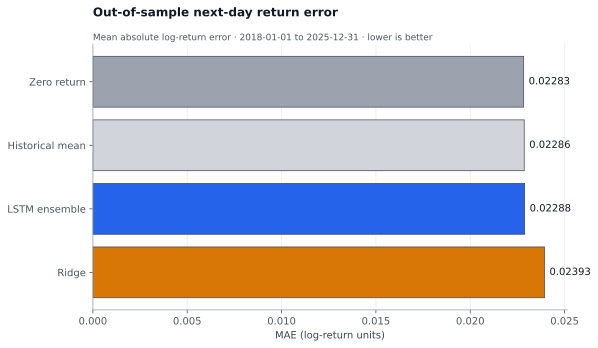

### Predicted versus realized returns

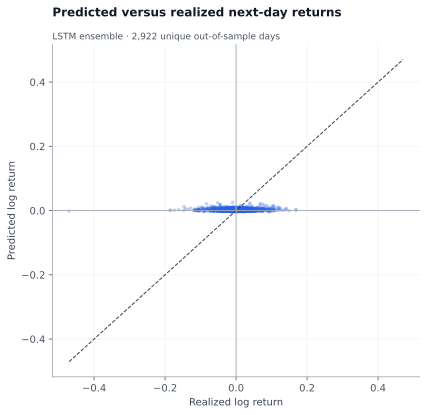

### Illustrative signal equity

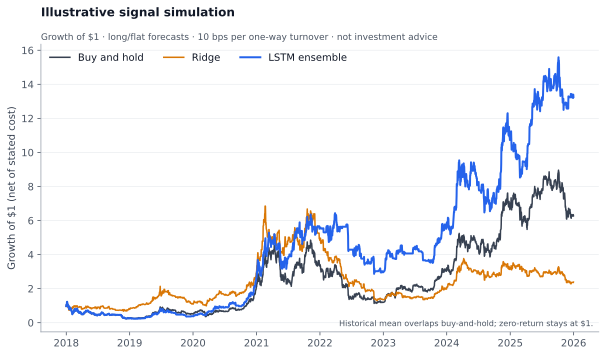

### Walk-forward fold design

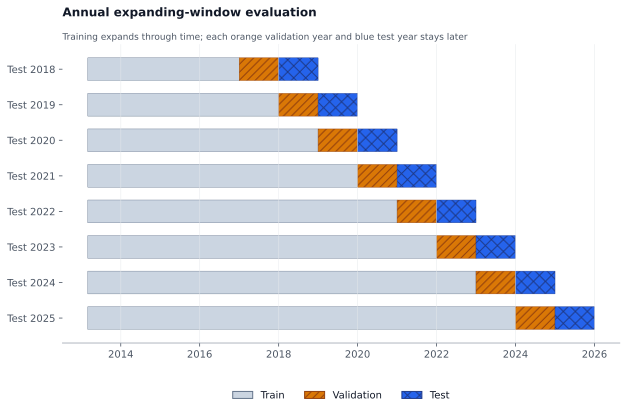

In [8]:
figures = (
    ("forecast_mae.svg", "Forecast MAE"),
    ("forecast_scatter.svg", "Predicted versus realized returns"),
    ("signal_equity.svg", "Illustrative signal equity"),
    ("walk_forward_folds.svg", "Walk-forward fold design"),
)
for filename, title in figures:
    display(Markdown(f"### {title}"))
    display(SVG(filename=str(FIGURE_DIRECTORY / filename)))

## Takeaways

The value of this project is the auditable evaluation design: pinned data,
origin-time features, chronological folds, strong simple baselines, seed
sensitivity, checksum-bound evidence, and explicit limits. The final cell
states the result from the verified bundle without turning historical error
differences or an idealized simulation into a profitability claim.

In [9]:
lower, upper = (float(value) for value in interval)
crosses_zero = lower <= 0.0 <= upper
baseline_name = comparison["best_baseline"]
if comparison["beats_best_baseline"]:
    ranking_sentence = f"LSTM aggregate MAE is lower than `{baseline_name}`."
else:
    ranking_sentence = f"LSTM does not beat `{baseline_name}` on aggregate MAE."
uncertainty_sentence = (
    "The block-bootstrap interval crosses zero, so the observed MAE ordering is "
    "not cleanly separated under this uncertainty check."
    if crosses_zero
    else "The block-bootstrap interval does not cross zero for this frozen sample."
)
display(
    Markdown(
        f"- {ranking_sentence}\n"
        f"- {uncertainty_sentence}\n"
        "- The 2025 test fold and three seed runs should be considered alongside the "
        "aggregate, not treated as footnotes.\n"
        "- The signal simulation is secondary and idealized; none of these outputs "
        "establish future predictability or justify a live trading decision.\n"
        "- Reproduction belongs in the CLI pipeline. This notebook remains a "
        "checksum-verifying presentation layer and performs no retraining."
    )
)

- LSTM does not beat `zero_return` on aggregate MAE.
- The block-bootstrap interval crosses zero, so the observed MAE ordering is not cleanly separated under this uncertainty check.
- The 2025 test fold and three seed runs should be considered alongside the aggregate, not treated as footnotes.
- The signal simulation is secondary and idealized; none of these outputs establish future predictability or justify a live trading decision.
- Reproduction belongs in the CLI pipeline. This notebook remains a checksum-verifying presentation layer and performs no retraining.